# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**


## Sección 1 - Cargar y explorar el dataset

In [54]:
# Importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



### Cargar Dataset

In [55]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [56]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
**La columna edad requiere un ajuste en el tipo de datos a int64 donde se contemplan datos enteros unicamente.**


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y**no requieren transformación adicional.**

In [57]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [58]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [59]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: 
Diagnóstico inicial de variables numéricas

- `edad` — La columna edad fue cargada como float64 por el formato del archivo fuente. Se realizó la conversión a int64 para representar las edades como números enteros, ya que no tiene sentido manejar decimales en esta variable.

#### Explorar variables binarias

In [60]:
# Verificar que cada columna tenga únicamente dos valores posibles
df['miembro_premium'].value_counts()

0    12911
1     2089
Name: miembro_premium, dtype: int64

In [61]:
# Verificar que cada columna tenga únicamente dos valores posibles
df['abandono'].value_counts()


0    12739
1     2261
Name: abandono, dtype: int64

In [62]:
df.duplicated().sum()

0

✍️ Diagnóstico inicial de variables binarias

- `miembro_premium` — el porcentaje de miembros premium es de 13.9% mientras los que no 86.1%
- `abandono` — el porcentaje de abandono es de 15.07% mientras los que no abandonan 84.93%



#### Explorar variables categóricas

In [63]:
# Verificar el número de valores únicos por variable categórica
df['tipo_dispositivo'].value_counts(normalize=True)


móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

In [64]:
df['region'].value_counts(normalize=True)

norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64

✍️ Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — El tipo de dispositivo dominante es el móvil siendo que cuenta con un 65% de uso
- `region` - Las regiones tienen una proporción equivalente. 
- `duplicados` - No hay valores duplicados, por lo tanto no es necesario eliminar registros repetidos. 


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

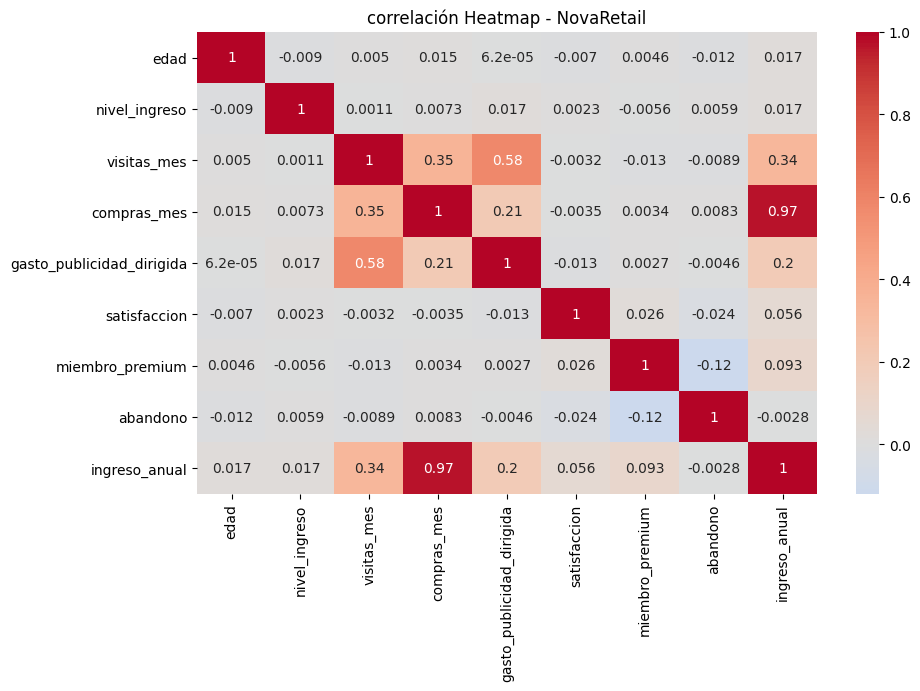

In [65]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm',center=0)
plt.title('correlación Heatmap - NovaRetail')
plt.show()


✍️ Observaciones generales (Heatmap)  
- Se observa que compras_mes vs ingreso_anual se encuentra en una categoria de relacion fuerte, quiere decir que el ingreso anual esta fuertemente relacionado con las compras que se hacen mensualmente


Observaciones respecto a `ingreso_anual`  
- Presenta una relacion debil con visitas_mes y gasto_publicidad_dirigida. No es relevante.


### Scatterplot general


- Se genera scatterplot con compras_mes vs ingreso_anual, debido a que son las variables que tienen una relación fuerte


<AxesSubplot:xlabel='compras_mes', ylabel='ingreso_anual'>

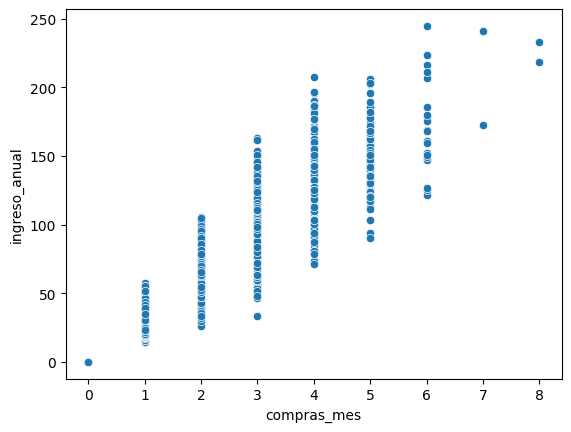

In [66]:
sns.scatterplot(x='compras_mes',y='ingreso_anual',data=df)

### Scatterplot para pares clave

✍️ Compras_mes vs ingreso_anual (relacion fuerte)
- Tendencia ascendente, confirma visualmente que a medida que aumenta compras_mes, tiende a aumentar ingreso_anual, es decir, tiene una relación fuerte y positiva.
- Lineas verticales, compras_mes es una variable discreta y toma pocos valores distintos en los cuales los clientes estan organizados por el numero de compras, por eso se ven lineas y no una nube continua

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [67]:
# Calcular correlación entre variables relevantes
df['compras_mes'].corr(df['ingreso_anual'],method='pearson')

0.9671485435708564

✍️ Observaciones de correlación

**compras_mes vs ingreso_anual** (~ 0.97)
- Correlación fuerte y positiva, por lo tanto se fundamenta lo visto en el Heatmap y Scatterplot


### Punto-biserial

In [68]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
coef, p_valor =pointbiserialr(df['miembro_premium'],df['ingreso_anual'])
print(coef, p_valor)

0.0930994396198015 3.0943076155242597e-30


In [69]:
from scipy.stats import pointbiserialr
coef, p_valor =pointbiserialr(df['abandono'],df['ingreso_anual'])
print(coef, p_valor)

-0.002823934021617148 0.7294691719078393


✍️ Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación débil (coeficiente de 0.093, cercano a 0) pero estadisticamente significativo (3.09e-30). Ser miembro premium puede tener alguna sociación real con el ingreso anual pero esa asociación es pequeña no es un factor que explique gran parte de las diferencias en ingreso

**abandono vs ingreso_anual** 

- Relacion débil negativa (coeficiente -0.0028) y estadisticamente insignificante por tener valor de (0.729)


### V de Cramér

In [70]:
# Función para calcular V de Cramér (tipo_dispositivo vs miembro_premium)
from scipy.stats import chi2_contingency
tabla=pd.crosstab(df['tipo_dispositivo'],df['miembro_premium'])
print(tabla)

miembro_premium      0     1
tipo_dispositivo            
escritorio        3245   475
móvil             8420  1398
tablet            1246   216


In [71]:
# Aplicar V de Cramér en variables relevantes
estadistico,p,dot,expected = chi2_contingency(tabla)
print(estadistico)

5.836391466827039


In [72]:
n=tabla.sum().sum()
cramers_v=np.sqrt(estadistico/(n*(min(tabla.shape)-1)))
print(cramers_v)

0.01972543445542166


In [73]:
# Función para calcular V de Cramér (region vs miembro_premium)
from scipy.stats import chi2_contingency
tabla2=pd.crosstab(df['region'],df['miembro_premium'])
print(tabla)

miembro_premium      0     1
tipo_dispositivo            
escritorio        3245   475
móvil             8420  1398
tablet            1246   216


In [74]:
# Aplicar V de Cramér en variables relevantes
estadistico2,p,dot,expected = chi2_contingency(tabla2)
print(estadistico2)

2.371651182308931


In [75]:
n=tabla2.sum().sum()
cramers_v2=np.sqrt(estadistico2/(n*(min(tabla.shape)-1)))
print(cramers_v2)

0.012574183027958334


✍️ Observaciones V de Cramér
la relación entre tipo_dispositivo vs miembro premium, es débil con un 0.0197 en v de Cramér
la relacion entre region vs miembro premium, es aun mas débil con un 0.0126 en v de Cramér


## Sección 5 - Interpretación de resultados para el negocio

✍️ **Hallazgos**:

### Hallazgo 1 — Las compras mensuales son el principal motor del ingreso anual

**Evidencia visual:**  
El scatterplot de compras_mes vs ingreso_anual muestra una tendencia ascendente clara y consistente — a mayor número de compras por mes, mayor ingreso anual generado por el cliente.

**Evidencia numérica:** 
Correlación de Pearson = 0.97 — correlación fuerte y positiva, la más alta observada en el análisis.

**Interpretación**  
Los clientes que compran con mayor frecuencia mensual generan significativamente más ingreso anual para NovaRetail+. Esta es la variable con mayor poder explicativo de todas las analizadas.

**No podemos afirmar**  
Que aumentar artificialmente las compras (por ejemplo, mediante descuentos agresivos) incrementará el ingreso anual de forma proporcional — la relación es asociativa, no causal. Tampoco podemos afirmar que los clientes de alto ingreso compran más porque están más satisfechos con la plataforma.

**Implicación de negocio**  
La frecuencia de compra es la palanca más directa sobre el ingreso. Estrategias de retención, programas de recompra, recordatorios personalizados y ofertas por volumen deben priorizarse sobre cualquier otra iniciativa — cada compra adicional por mes tiene un impacto comprobado en el ingreso anual del cliente.

### Hallazgo 2 — Ser miembro premium tiene una asociación real pero pequeña con el ingreso anual

**Evidencia visual:** 
No se generó una visualización específica para esta relación, pero el análisis de punto-biserial provee evidencia numérica suficiente.

**Evidencia numérica:** 
Correlación punto-biserial miembro_premium vs ingreso_anual = 0.093, con p-valor = 3.09e-30 (estadísticamente significativo).

**Interpretación**  
Aunque la asociación entre ser miembro premium y el ingreso anual es débil en magnitud, es estadísticamente real — no es un resultado aleatorio. Los clientes premium generan marginalmente más ingreso que los no premium, pero la diferencia no es grande en términos prácticos.

**No podemos afirmar**  
Convertir más clientes a premium aumentará directamente el ingreso anual. El bajo coeficiente sugiere que la membresía premium, por sí sola, no es el factor que define el nivel de ingreso de un cliente — posiblemente los clientes premium ya tenían alta frecuencia de compra antes de suscribirse.

**Implicación de negocio**  
El programa premium no debe diseñarse como una palanca de ingreso directo, sino como un mecanismo de retención y fidelización. Su valor real puede estar en mantener activos a clientes que de otra forma abandonarían — no en aumentar su gasto por el solo hecho de tener la membresía.

### Hallazgo 3 — El abandono y las variables categóricas no tienen impacto significativo en el ingreso

**Evidencia numérica:** 
- abandono vs ingreso_anual: coeficiente = -0.0028, p-valor = 0.729 (no significativo)
- tipo_dispositivo vs miembro_premium: V de Cramér = 0.0197 (asociación muy débil)
- region vs miembro_premium: V de Cramér = 0.0126 (asociación prácticamente nula)

**Interpretación**  
Ni el tipo de dispositivo, ni la región, ni el abandono muestran una asociación relevante con el ingreso anual o con la membresía premium. Las diferencias entre regiones y dispositivos son estadísticamente insignificantes.

**No podemos afirmar**  
Que optimizar la experiencia por dispositivo o diseñar estrategias regionales diferenciadas impactará el ingreso anual de forma medible, basándonos únicamente en estos datos.

**Implicación de negocio**  
Los recursos de segmentación no deben orientarse por región o dispositivo — al menos no para maximizar ingreso. El foco debe estar en el comportamiento de compra, independientemente de dónde o cómo accede el cliente a la plataforma.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad - todos los hallazgos son asociaciones observadas, no relaciones causa-efecto. No podemos afirmar que modificar una variable producirá un cambio directo en el ingreso anual.

- Un solo periodo — el dataset cubre el comportamiento en 2024 sin datos históricos. No es posible evaluar tendencias o cambios de comportamiento en el tiempo.

- Variables no capturadas — factores como historial de compras, categorías de productos, descuentos aplicados o canal de adquisición del cliente podrían explicar mejor las variaciones en ingreso anual.

- Clientes con abandono = 1 — estos clientes siguen en el dataset. Incluirlos puede afectar el análisis de ingreso si sus patrones de comportamiento son distintos a los clientes activos.

### **Próximos pasos** 

Profundizar en compras_mes
- Segmentar clientes por frecuencia de compra (bajo, medio, alto) y comparar su ingreso anual promedio
- Analizar qué características comparten los clientes de alta frecuencia para identificar perfiles replicables

Explorar la membresía premium con mayor detalle
- Comparar el ingreso anual antes y después de que un cliente se convierte a premium
- Evaluar si los clientes premium tienen menor tasa de abandono que los no premium
